In [36]:
from jupyter_client import channels
from langchain_core.messages import HumanMessage

from agent.sub_agents.research_agent import _builder,_web_search,research_agent_graph
from agent.graph import generate_plan,evaluate_plan,graph
from IPython.display import Image, display,Markdown
from agent.state import OverallState
from rich import print as rprint
from langchain_core.runnables import RunnableConfig


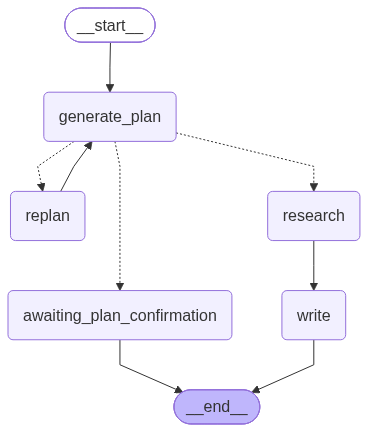

{
    'messages': <langgraph.channels.binop.BinaryOperatorAggregate object at 0x111edcf80>,
    'plan': <langgraph.channels.last_value.LastValue object at 0x111dfe0c0>,
    'plan_status': <langgraph.channels.last_value.LastValue object at 0x110e5a900>,
    'plan_messages': <langgraph.channels.binop.BinaryOperatorAggregate object at 0x111edc940>,
    'search_query': <langgraph.channels.binop.BinaryOperatorAggregate object at 0x111edf100>,
    'web_search_result': <langgraph.channels.binop.BinaryOperatorAggregate object at 0x111edcf40>,
    'sources_gathered': <langgraph.channels.binop.BinaryOperatorAggregate object at 0x111edcd80>,
    'initial_search_query_count': <langgraph.channels.last_value.LastValue object at 0x111edfe00>,
    'max_research_loops': <langgraph.channels.last_value.LastValue object at 0x111edd100>,
    'research_loop_count': <langgraph.channels.last_value.LastValue object at 0x111edd7c0>,
    'reasoning_model': <langgraph.channels.last_value.LastValue object at 0x111ede800>,
    'report_outline': <langgraph.channels.last_value.LastValue object at 0x111edf940>,
    'report_draft': <langgraph.channels.last_value.LastValue object at 0x111edc1c0>,
    'is_sufficient': <langgraph.channels.last_value.LastValue object at 0x111edee00>,
    'knowledge_gap': <langgraph.channels.last_value.LastValue object at 0x111edf580>,
    'follow_up_queries': <langgraph.channels.binop.BinaryOperatorAggregate object at 0x111edd2c0>,
    'number_of_ran_queries': <langgraph.channels.last_value.LastValue object at 0x111edf780>,
    '__start__': <langgraph.channels.ephemeral_value.EphemeralValue object at 0x111eddf00>,
    '__pregel_tasks': <langgraph.channels.topic.Topic object at 0x111eea280>,
    'branch:to:generate_plan': <langgraph.channels.ephemeral_value.EphemeralValue object at 0x111eeae80>,
    'branch:to:replan': <langgraph.channels.ephemeral_value.EphemeralValue object at 0x111edcfc0>,
    'branch:to:awaiting_plan_confirmation': <langgraph.channels.ephemeral_value.EphemeralValue object at 
0x111edfac0>,
    'branch:to:research': <langgraph.channels.ephemeral_value.EphemeralValue object at 0x111eeb640>,
    'branch:to:write': <langgraph.channels.ephemeral_value.EphemeralValue object at 0x111eea500>
}

In [41]:
display(Image(graph.get_graph().draw_mermaid_png()))

rprint(graph.channels)

# for g in graph.get_subgraphs():
#     print(g[0])
#     display(Image(g[1].get_graph().draw_mermaid_png()))

In [37]:

input = OverallState(
    messages=[HumanMessage('帮我调研现在企业 AI Agent 在实际业务中的落地方案，主要是 酒店旅游行业')],
    initial_search_query_count=5
)
config: RunnableConfig = RunnableConfig(configurable={
    "number_of_initial_queries":3,
    "query_generator_model":"MiniMax-M3"
})

In [ ]:
plans = generate_plan(input,config)

In [40]:

for p in plans:
    rprint(p)


messages

plan

plan_status

plan_messages

In [48]:
channels = graph.channels
def merge_by_schema(state_old: dict, state_new: dict):
    """按照state定义的reducer合并两个state dict"""
    result = dict(state_old)
    for field_name, channel in channels.items():
        old_val = state_old.get(field_name)
        new_val = state_new.get(field_name)
        if new_val is None:
            continue
        # 使用该字段注册的channel/reducer做合并
        result[field_name] = channel.update( new_val)
    return result

rprint(input)

# rprint(plans)

merges = merge_by_schema( input,  plans)
rprint(merges)

{
    'messages': [
        HumanMessage(
            content='帮我调研现在企业 AI Agent 在实际业务中的落地方案，主要是 酒店旅游行业',
            additional_kwargs={},
            response_metadata={}
        )
    ],
    'initial_search_query_count': 5
}


KeyboardInterrupt



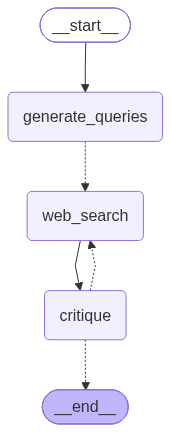

In [8]:

display(Image(research_agent_graph.get_graph().draw_mermaid_png()))


In [ ]:


output = research_agent_graph.invoke(input)


In [11]:
output

{'messages': [HumanMessage(content='帮我调研现在企业 AI Agent 在实际业务中的落地方案，主要是 酒店旅游行业', additional_kwargs={}, response_metadata={}, id='148756cb-9eec-49b4-b1e4-18ef3542250d')],
 'plan_messages': [],
 'search_query': ['酒店行业AI Agent应用案例 2025 2026',
  '旅游行业人工智能代理落地方案 2025',
  '酒店旅游行业AI智能体解决方案供应商',
  '酒店旅游业AI Agent实施挑战与最佳实践',
  '酒店旅游行业生成式AI大模型应用 2025 2026',
  '酒店行业AI Agent应用案例 2025 2026',
  '旅游行业人工智能代理落地方案 2025',
  '酒店旅游行业AI智能体解决方案供应商',
  '酒店旅游业AI Agent实施挑战与最佳实践',
  '酒店旅游行业生成式AI大模型应用 2025 2026',
  '酒店集团AI Agent投资回报率ROI案例分析 2025-2026 不同酒店档次经济型中端高端',
  '万豪希尔顿洲际酒店AI Agent人工智能代理落地实践案例 2025 投入规模实施路径',
  '酒店旅游行业AI Agent实施失败案例分析 风险管控 合规要求数据安全',
  'AI Agent与酒店PMS系统集成技术方案 API接口标准 实施周期技术门槛 2025',
  '酒店行业AI人才培养体系 员工AI技能培训 行业人才缺口 数据 2025-2026'],
 'web_search_result': ['## 酒店行业AI Agent应用案例整合（2025-2026）\n\n### 一、头部酒店集团AI实践\n\n**锦江酒店"锦鲲"AI项目**是当前酒店行业AI Agent应用的典型代表。自2025年起，锦江酒店（中国区）推进该AI项目，鼓励员工提出实际业务问题并运用AI工具解决。在2026年"鲲书尖子班·AI效率先锋大赛"中，13个已投入实际经营的创新案例脱颖而出：\n\n- **AI食材质检系统**：员工可通过拍照扫描方式，自动检查食材库存、保质期并进行预警\n- **AI渠道智

In [ ]:
rprint(len(output.get('web_search_result')))

print_count = 1
for tmp_result in output.get('web_search_result',[]):
    print('\n\n\n\n','*'*100)
    if print_count <= 0:
        break
    display(Markdown(tmp_result))
    print_count -= 1


In [21]:
from agent.sub_agents.writer_agent import _builder, writer_agent_graph


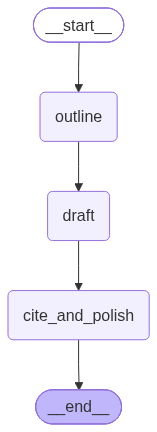

In [22]:
display(Image(writer_agent_graph.get_graph().draw_mermaid_png()))


In [23]:

write_output:OverallState =writer_agent_graph.invoke(output)


2026-09-04 13:12:49.139 | INFO     | agent.sub_agents.writer_agent:_outline:45 - [WriterAgent] outline using model=MiniMax-M2.7
2026-09-04 13:13:13.902 | INFO     | agent.sub_agents.writer_agent:_outline:55 - [WriterAgent] outline 已生成 (648 字)
2026-09-04 13:13:13.908 | INFO     | agent.sub_agents.writer_agent:_draft:63 - [WriterAgent] drafting using model=MiniMax-M2.7


KeyboardInterrupt: 

In [ ]:
write_output